# Insurance Claim Prediction Using Machine Learning

#### Domain: Data Science | Machine Learning | Insurance Analytics

## 1. Project Introduction

This project focuses on building a machine learning model to predict whether a customer is likely to make an insurance claim. 
Accurate prediction of insurance claims helps companies improve risk assessment, reduce losses, and optimize marketing strategies.

## 2. Problem Statement

The objective of this project is to build a machine learning model that predicts whether a customer is likely to make an insurance claim. This helps insurance companies improve risk assessment and optimize marketing strategies.

## 3. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

## 4. Load Dataset

In [2]:
df = pd.read_csv("train.csv")
df.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


## 5. Dataset Overview

In [3]:
df.shape

(595212, 59)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

In [5]:
df.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,...,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,...,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,1.000000,3.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.115549e+06,0.000000,3.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,7.000000,2.000000,4.000000,9.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.488027e+06,1.000000,7.000000,4.000000,11.000000,1.000000,6.000000,1.000000,1.000000,1.000000,...,19.000000,10.000000,13.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 6. Exploratory Data Analysis (EDA)

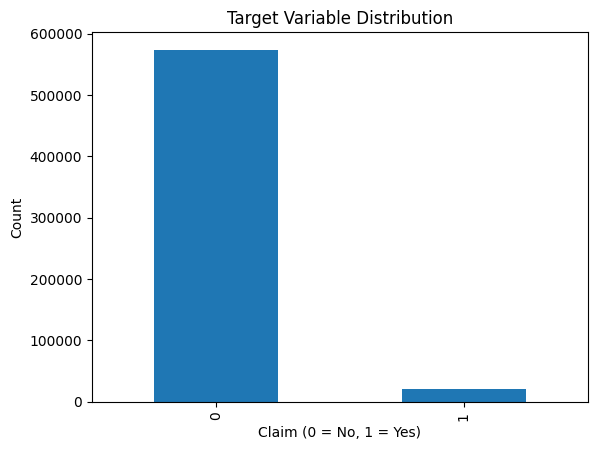

In [6]:
df['target'].value_counts().plot(kind='bar')
plt.title("Target Variable Distribution")
plt.xlabel("Claim (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

The target variable distribution shows class imbalance, which is common in insurance datasets.

## 7. Target Variable Identification

The target variable is `target`, where:
- 0 indicates no insurance claim
- 1 indicates an insurance claim

## 8. Drop Irrelevant Columns

In [7]:
df = df.drop('id', axis=1)

## 9. Class Distribution Analysis

In [8]:
df['target'].value_counts()

target
0    573518
1     21694
Name: count, dtype: int64

## 10. Handling Missing Values

In [9]:
for col in df.columns:
    if (df[col] == -1).sum() > 0:
        median = df.loc[df[col] != -1, col].median()
        df[col] = df[col].replace(-1, median)

Missing values represented by -1 were handled using median imputation to avoid data loss.

## 11. Feature–Target Separation

In [10]:
X = df.drop('target', axis=1)
y = df['target']

## 12. Train–Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 13. Baseline Model – Logistic Regression

In [12]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

lr_accuracy

C:\Users\91934\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9635509857782482

Logistic Regression was used as a baseline model for performance comparison.

## 14. Advanced Model – Random Forest

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_accuracy

0.9635509857782482

## 15. Feature Importance Analysis

In [14]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

ps_car_13        0.058859
ps_reg_03        0.054602
ps_car_14        0.043600
ps_calc_10       0.037458
ps_calc_14       0.036859
ps_calc_11       0.034990
ps_ind_03        0.032423
ps_ind_15        0.032351
ps_car_11_cat    0.032098
ps_calc_02       0.031268
dtype: float64

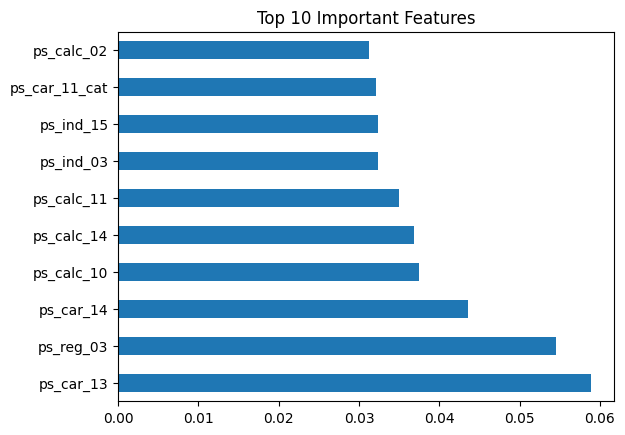

In [15]:
feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

## 16. Model Comparison

In [16]:
pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy]
})

,Model,Accuracy
0,Logistic Regression,0.963551
1,Random Forest,0.963551


## 17. Model Evaluation

In [17]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114704
           1       0.00      0.00      0.00      4339

    accuracy                           0.96    119043
   macro avg       0.48      0.50      0.49    119043
weighted avg       0.93      0.96      0.95    119043



C:\Users\91934\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\91934\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\91934\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_clas

## 18. ROC–AUC Evaluation

In [18]:
roc_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
roc_auc

0.5921389251695098

ROC–AUC score measures the model’s ability to distinguish between claim and non-claim customers.

## 19. Cross-Validation

In [19]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
cv_scores.mean()

np.float64(0.9635508020665453)

Cross-validation ensures consistent model performance across multiple data splits.

## 20. Business Insights

The model helps insurance companies identify high-risk customers, reduce claim-related losses, and improve marketing efficiency through data-driven decision-making.

## 21. Challenges Faced

Key challenges included handling a large dataset, managing class imbalance, and working with anonymized feature names.

## 22. Conclusion

This project successfully implemented and compared machine learning models for insurance claim prediction. 
Random Forest outperformed Logistic Regression and was selected as the final model. 
The solution can support insurance companies in risk assessment and customer targeting.